# Gridsearch — LightGBM (ILI / ARI)

Runs the stage-1 (RMSE), freze best params of stage-1 and then gridsearch stage-2 (WIS) using Optuna.

## Setup

In [ ]:
# Optional: install dependencies (uncomment if running in a fresh env / Colab)
# %pip install "lightgbm>=4.3" "lightgbmlss>=0.2.5" "optuna>=3.6"



In [ ]:
import pandas as pd
from pathlib import Path
import sys
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt


In [20]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "gridsearch_lgbm.py").exists():
            return p
    raise FileNotFoundError(
        "Could not locate repo root (src/gridsearch_lgbm.py not found above "
        f"{start}). Run this notebook from inside the MIGHTE-respicast-jointGBM checkout."
    )

ROOT_DIR = find_repo_root(Path.cwd())
print("Repo root:", ROOT_DIR)


Repo root: /home/nadillia/Documents/MIGHTE-respicast-jointGBM


In [ ]:
sys.path.insert(0, str(ROOT_DIR / "src"))

%load_ext autoreload
%autoreload 2

import gridsearch_lgbm as gs

print("import OK")


In [22]:
# Hub repo checkout (target-data + locations file). Also used below to refresh the canonical CSV.
HUB_DIR = ROOT_DIR / "RespiCast-SyndromicIndicators"
LOCATIONS_FILE = HUB_DIR / "supporting-files" / "locations_iso2_codes.csv"

if not LOCATIONS_FILE.exists():
    !git clone --depth 1 https://github.com/european-modelling-hubs/RespiCast-SyndromicIndicators.git "{HUB_DIR}"
else:
    !git -C "{HUB_DIR}" pull --ff-only


Already up to date.


## Config

Change `TARGET` to `"ILI"` or `"ARI"` and re-run from here down.

In [ ]:
TARGET = "ARI"  # ILI or "ARI"

DATA_FILE = ROOT_DIR / "data" / "processed" / "respicast_long_latest.csv"
GT_FILE = ROOT_DIR / "google_preprocessing" / "data" / "processed" / "google_trends_preprocessed.csv"  # preprocessed (denoised+detrended)
ANCHOR = "2026-08-02"
EXCLUDE_COVID = True
INCLUDE_GT_LEAD = True  # adds a GT "nowcast" lag-1 feature (GT ~1 week ahead of the anchor); set False to disable
GT_MIN_CORR = 0.3  # drop a GT term/location pair whose same-week |correlation| with the target is below this

SEED = 4321
CUTOFF_Q = 0.75

# Keep these small (e.g. 5) while debugging, restore for a real search.
N_TRIALS_STAGE1 = 70
N_TRIALS_STAGE2 = 60

OUTPUT_PATH = ROOT_DIR / f"best_params_ablation_{TARGET.lower()}.json"

OWN_LAGS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 26, 52]
DONOR_LAGS = [1, 2, 3, 4, 8, 12]
DONOR_TOP_K = 4
OTHER_TOP_K = 2

OTHER = "ARI" if TARGET == "ILI" else "ILI"
TARGET_COL, OTHER_COL = gs.TARGET_COLUMN[TARGET], gs.TARGET_COLUMN[OTHER]
print(f"target={TARGET_COL!r}  secondary={OTHER_COL!r}")


In [24]:
# Rebuild the canonical long series from the hub checkout — same step forecast_backtest.py /
# forecast_prospective.py run before every forecast, so DATA_FILE reflects the latest target-data.

from build_long_timeseries import resolve_long_timeseries

canonical = resolve_long_timeseries(HUB_DIR)
DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
canonical.to_csv(DATA_FILE, index=False)
print(f"Refreshed {DATA_FILE}: {len(canonical)} rows, "
      f"max truth_date={pd.to_datetime(canonical['truth_date']).max().date()}")


Refreshed /home/nadillia/Documents/MIGHTE-respicast-jointGBM/data/processed/respicast_long_latest.csv: 22310 rows, max truth_date=2026-08-02


## Build feature matrix

In [34]:
LOCATIONS = sorted(pd.read_csv(GT_FILE, usecols=["location"])["location"].astype(str).unique().tolist())
print(f"{len(LOCATIONS)} locations (from GT_FILE)")

# if TARGET == "ILI":
#     LOCATIONS = [loc for loc in LOCATIONS if loc not in {"CY", "IT"}]  # currently no ILI data for these countries 

# if TARGET == "ARI":
#     LOCATIONS = [loc for loc in LOCATIONS if loc not in {"MT"}]  # currently no ARI data for these countries


df, y, feat_cols = gs.build_matrix(
    DATA_FILE, TARGET_COL, OTHER_COL, LOCATIONS, pd.to_datetime(ANCHOR),
    EXCLUDE_COVID, OWN_LAGS, DONOR_LAGS, DONOR_TOP_K, OTHER_TOP_K,
    gt_file=str(GT_FILE), include_gt_lead=INCLUDE_GT_LEAD, gt_min_corr=GT_MIN_CORR,
)
print(f"{df.shape[0]} rows, {len(feat_cols)} features")
df.head()


32 locations (from GT_FILE)
[GT] correlation filter (|r| >= 0.3): 17 kept, 0 dropped
39949 rows, 272 features


,location,date,y,y_base,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,...,virus_lag4,virus_lag5,virus_lag6,virus_lag7,virus_lag8,horizon,target,target_end_date,horizon_sin,horizon_cos
0,AT,2014-10-05,589.6,589.6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,547.3,2014-10-12,0.707107,0.707107
1,AT,2014-10-12,547.3,547.3,589.6,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,768.8,2014-10-19,0.707107,0.707107
2,AT,2014-10-19,768.8,768.8,547.3,589.6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,696.1,2014-10-26,0.707107,0.707107
3,AT,2014-10-26,696.1,696.1,768.8,547.3,589.6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,762.6,2014-11-02,0.707107,0.707107
4,AT,2014-11-02,762.6,762.6,696.1,768.8,547.3,589.6,NaN,NaN,...,3742.921606,NaN,NaN,NaN,NaN,1,883.4,2014-11-09,0.707107,0.707107


## Stage 1 — RMSE search (num_leaves, learning_rate, min_child_samples, feature_fraction, rounds)

In [20]:
study_s1 = gs.run_stage1_study(
    gs.GT_VARIANT, df, y, feat_cols, SEED, N_TRIALS_STAGE1, CUTOFF_Q, verbose=True,
)
stage1_best = {**study_s1.best_params, "rounds": study_s1.best_trial.user_attrs["best_round"]}
print(f"best stage-1 RMSE = {study_s1.best_value:.3f}")
stage1_best


=== Stage 1 (RMSE) optimizing: gt_proc ===


Best trial: 67. Best value: 685.809: 100%|██████████| 70/70 [50:06<00:00, 42.95s/it]

best stage-1 RMSE = 685.809


{'num_leaves': 79,
 'learning_rate': 0.0014017429596073063,
 'min_child_samples': 98,
 'feature_fraction': 0.9111152147885835,
 'rounds': 1000}

In [21]:
# Inspect trial history if needed
study_s1.trials_dataframe().sort_values("value").head(10)


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_child_samples,params_num_leaves,user_attrs_best_round,state
67,67,685.809222,2026-08-19 14:05:55.657347,2026-08-19 14:06:43.234336,0 days 00:00:47.576989,0.911115,0.001402,98,79,1000,COMPLETE
25,25,686.575883,2026-08-19 13:35:28.349564,2026-08-19 13:36:19.527077,0 days 00:00:51.177513,0.852535,0.001476,99,93,1000,COMPLETE
65,65,686.587553,2026-08-19 14:04:29.980335,2026-08-19 14:05:13.026627,0 days 00:00:43.046292,0.905372,0.001454,95,66,1000,COMPLETE
54,54,687.161809,2026-08-19 13:57:12.158055,2026-08-19 13:57:57.053297,0 days 00:00:44.895242,0.895658,0.001507,96,71,1000,COMPLETE
66,66,687.912299,2026-08-19 14:05:13.028350,2026-08-19 14:05:55.655782,0 days 00:00:42.627432,0.908632,0.001385,98,65,1000,COMPLETE
61,61,688.918266,2026-08-19 14:01:36.254452,2026-08-19 14:02:20.988368,0 days 00:00:44.733916,0.893452,0.001667,97,71,1000,COMPLETE
62,62,689.197465,2026-08-19 14:02:20.989953,2026-08-19 14:03:02.618863,0 days 00:00:41.628910,0.887301,0.001300,98,64,1000,COMPLETE
19,19,689.384274,2026-08-19 13:30:21.258137,2026-08-19 13:31:10.722519,0 days 00:00:49.464382,0.846488,0.001534,100,89,1000,COMPLETE
57,57,692.365510,2026-08-19 13:59:24.308761,2026-08-19 14:00:07.660697,0 days 00:00:43.351936,0.922589,0.001673,96,65,1000,COMPLETE
48,48,692.449867,2026-08-19 13:52:46.711285,2026-08-19 13:53:29.324805,0 days 00:00:42.613520,0.854570,0.001658,90,69,1000,COMPLETE


## Stage 1 — training vs validation learning curve

Trains once with the tuned stage-1 params out to a generous max round count (no early stopping), tracking cases-space RMSE (same units/metric the Optuna search minimized) on both splits every round. The vertical line marks the round count early stopping actually picked during the search above — rounds trained past that line are the overfitting region.

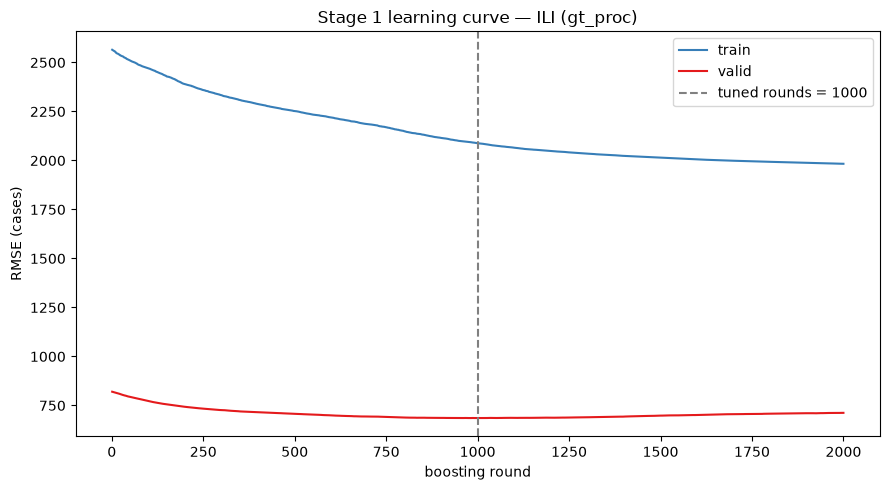

In [22]:
cut = df["date"].quantile(CUTOFF_Q)
tr_mask = (df["date"] <= cut).to_numpy()
X_tr, y_tr = df.loc[tr_mask, feat_cols].astype(float), y[tr_mask]
X_va, y_va = df.loc[~tr_mask, feat_cols].astype(float), y[~tr_mask]

base_tr = np.log1p(np.clip(df.loc[tr_mask, "y_base"].to_numpy(float), 0, None))
base_va = np.log1p(np.clip(df.loc[~tr_mask, "y_base"].to_numpy(float), 0, None))
actual_tr = df.loc[tr_mask, "target"].to_numpy(float)
actual_va = df.loc[~tr_mask, "target"].to_numpy(float)

p1 = {
    "objective": "regression", "metric": "l2",
    "learning_rate": stage1_best["learning_rate"],
    "num_leaves": stage1_best["num_leaves"],
    "min_child_samples": stage1_best["min_child_samples"],
    "feature_fraction": stage1_best["feature_fraction"],
    "bagging_fraction": 0.9, "bagging_freq": 1,
    "seed": SEED, "deterministic": True, "force_row_wise": True,
    "verbosity": -1,
}
MAX_ROUNDS_S1 = max(1500, stage1_best["rounds"] * 2)

d_tr = lgb.Dataset(X_tr, label=y_tr)
d_va = lgb.Dataset(X_va, label=y_va, reference=d_tr)

def _cases_rmse_feval(preds, dataset):
    base, actual = (base_tr, actual_tr) if dataset is d_tr else (base_va, actual_va)
    pred_cases = np.maximum(np.expm1(preds + base), 0.0)
    return "cases_rmse", float(np.sqrt(np.mean((pred_cases - actual) ** 2))), False

evals_result = {}
lgb.train(
    p1, d_tr,
    num_boost_round=MAX_ROUNDS_S1,
    valid_sets=[d_tr, d_va],
    valid_names=["train", "valid"],
    feval=_cases_rmse_feval,
    callbacks=[lgb.record_evaluation(evals_result)],
)

rounds = np.arange(1, MAX_ROUNDS_S1 + 1)
plt.figure(figsize=(9, 5))
plt.plot(rounds, evals_result["train"]["cases_rmse"], label="train", color="#377EB8")
plt.plot(rounds, evals_result["valid"]["cases_rmse"], label="valid", color="#E41A1C")
plt.axvline(stage1_best["rounds"], color="gray", linestyle="--", label=f"tuned rounds = {stage1_best['rounds']}")
plt.xlabel("boosting round")
plt.ylabel("RMSE (cases)")
plt.title(f"Stage 1 learning curve — {TARGET} ({gs.GT_VARIANT})")
plt.legend()
plt.tight_layout()
plt.show()


## Stage 2 — WIS search (stage2_rounds, lambda_l2, s2_min_child_samples), frozen on stage-1 rounds

In [23]:
study_s2 = gs.run_stage2_study(
    gs.GT_VARIANT, df, y, feat_cols, stage1_best, SEED, N_TRIALS_STAGE2, CUTOFF_Q, verbose=True,
)
print(f"best stage-2 WIS = {study_s2.best_value:.4f}")
study_s2.best_params


=== Stage 2 (WIS) optimizing: gt_proc  (stage1 rounds frozen at 1000) ===


Best trial: 49. Best value: 120.606: 100%|██████████| 60/60 [55:09<00:00, 55.15s/it]

best stage-2 WIS = 120.6065


{'stage2_rounds': 229,
 'lambda_l2': 0.13230930634474714,
 's2_min_child_samples': 20}

In [24]:
study_s2.trials_dataframe().sort_values("value").head(10)


,number,value,datetime_start,datetime_complete,duration,params_lambda_l2,params_s2_min_child_samples,params_stage2_rounds,state
49,49,120.606496,2026-08-19 14:57:28.698611,2026-08-19 14:58:26.184106,0 days 00:00:57.485495,0.132309,20,229,COMPLETE
55,55,120.819118,2026-08-19 15:03:09.784096,2026-08-19 15:04:06.867215,0 days 00:00:57.083119,0.143235,12,231,COMPLETE
53,53,120.820881,2026-08-19 15:01:15.839134,2026-08-19 15:02:13.531838,0 days 00:00:57.692704,0.119083,15,241,COMPLETE
51,51,120.828680,2026-08-19 14:59:21.188653,2026-08-19 15:00:18.291621,0 days 00:00:57.102968,0.118230,15,226,COMPLETE
50,50,120.842050,2026-08-19 14:58:26.185645,2026-08-19 14:59:21.187146,0 days 00:00:55.001501,0.126601,19,228,COMPLETE
57,57,120.847181,2026-08-19 15:05:03.998926,2026-08-19 15:06:01.904053,0 days 00:00:57.905127,0.084515,28,241,COMPLETE
52,52,120.856198,2026-08-19 15:00:18.293030,2026-08-19 15:01:15.837770,0 days 00:00:57.544740,0.110755,13,229,COMPLETE
56,56,120.892173,2026-08-19 15:04:06.868558,2026-08-19 15:05:03.997158,0 days 00:00:57.128600,0.126164,15,227,COMPLETE
45,45,120.950064,2026-08-19 14:53:50.782739,2026-08-19 14:54:44.137763,0 days 00:00:53.355024,0.234385,12,220,COMPLETE
23,23,120.981912,2026-08-19 14:33:32.557597,2026-08-19 14:34:29.886733,0 days 00:00:57.329136,0.106929,45,250,COMPLETE


## Stage 2 — training vs validation learning curve

LightGBMLSS doesn't expose a per-round WIS metric during training the way stage 1 does, so this refits a full stage-1+stage-2 model at each round count in a grid (using the tuned stage-1 params/rounds and tuned stage-2 `lambda_l2`/`s2_min_child_samples`, varying only `stage2_rounds`) and scores WIS on train/valid at each point. This is slower than the stage-1 cell — narrow `S2_ROUND_GRID` below if it's too slow.

  rounds=  10  train WIS=125.879  valid WIS=121.559
  rounds=  30  train WIS=125.704  valid WIS=121.416
  rounds=  50  train WIS=125.626  valid WIS=121.334
  rounds=  70  train WIS=125.551  valid WIS=121.259
  rounds=  90  train WIS=125.422  valid WIS=121.139
  rounds= 110  train WIS=125.192  valid WIS=121.004
  rounds= 130  train WIS=125.119  valid WIS=120.941
  rounds= 150  train WIS=125.037  valid WIS=120.871
  rounds= 170  train WIS=124.927  valid WIS=120.789
  rounds= 190  train WIS=124.863  valid WIS=120.725
  rounds= 210  train WIS=124.798  valid WIS=120.673
  rounds= 229  train WIS=124.714  valid WIS=120.606
  rounds= 230  train WIS=124.711  valid WIS=120.604
  rounds= 250  train WIS=124.637  valid WIS=120.551


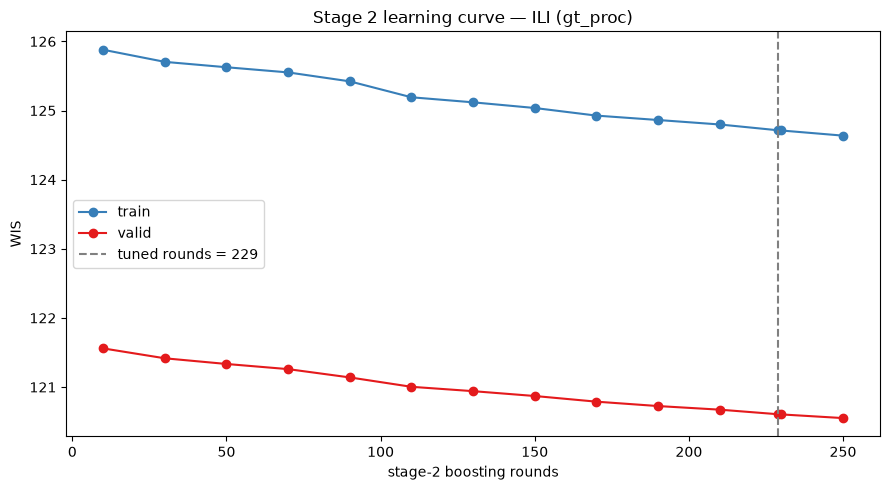

In [25]:
cut = df["date"].quantile(CUTOFF_Q)
tr_mask = (df["date"] <= cut).to_numpy()
X_tr, y_tr = df.loc[tr_mask, feat_cols].astype(float), y[tr_mask]
X_va = df.loc[~tr_mask, feat_cols].astype(float)
base_tr = df.loc[tr_mask, "y_base"].to_numpy(float)
base_va = df.loc[~tr_mask, "y_base"].to_numpy(float)
actual_tr = df.loc[tr_mask, "target"].to_numpy(float)
actual_va = df.loc[~tr_mask, "target"].to_numpy(float)
ok_tr = np.isfinite(actual_tr)
ok_va = np.isfinite(actual_va)

s2_params = study_s2.best_params
tuned_rounds = s2_params["stage2_rounds"]

S2_ROUND_GRID = sorted(set(list(range(10, 261, 20)) + [tuned_rounds]))

train_wis, valid_wis = [], []
for r in S2_ROUND_GRID:
    stage1_r, stage2_r = gs.fit_two_stage_one_bag(
        X_train=X_tr, y_train=y_tr,
        stage1_rounds=stage1_best["rounds"], seed=SEED,
        num_leaves=stage1_best["num_leaves"], learning_rate=stage1_best["learning_rate"],
        min_child_samples=stage1_best["min_child_samples"], feature_fraction=stage1_best["feature_fraction"],
        stage2_rounds=r, sigma_mode="bounded",
        lambda_l2=s2_params["lambda_l2"], s2_min_child_samples=s2_params["s2_min_child_samples"],
        s2_num_leaves=None, s2_learning_rate=None, s2_feature_fraction=None, s2_max_depth=6,
    )

    pq_tr = gs.predict_quantiles(stage1_r, stage2_r, X_tr, gs.QUANTILES, target_mode="delta_log", current_obs=base_tr)
    pq_tr = np.clip(np.nan_to_num(pq_tr, nan=0.0, posinf=1e7, neginf=0.0), 0.0, 1e7)
    train_wis.append(float(np.mean(gs.wis_vectorized(pq_tr[ok_tr], actual_tr[ok_tr], gs.QUANTILES))))

    pq_va = gs.predict_quantiles(stage1_r, stage2_r, X_va, gs.QUANTILES, target_mode="delta_log", current_obs=base_va)
    pq_va = np.clip(np.nan_to_num(pq_va, nan=0.0, posinf=1e7, neginf=0.0), 0.0, 1e7)
    valid_wis.append(float(np.mean(gs.wis_vectorized(pq_va[ok_va], actual_va[ok_va], gs.QUANTILES))))

    print(f"  rounds={r:>4d}  train WIS={train_wis[-1]:.3f}  valid WIS={valid_wis[-1]:.3f}")

plt.figure(figsize=(9, 5))
plt.plot(S2_ROUND_GRID, train_wis, marker="o", label="train", color="#377EB8")
plt.plot(S2_ROUND_GRID, valid_wis, marker="o", label="valid", color="#E41A1C")
plt.axvline(tuned_rounds, color="gray", linestyle="--", label=f"tuned rounds = {tuned_rounds}")
plt.xlabel("stage-2 boosting rounds")
plt.ylabel("WIS")
plt.title(f"Stage 2 learning curve — {TARGET} ({gs.GT_VARIANT})")
plt.legend()
plt.tight_layout()
plt.show()


## Pack + save

In [35]:
best = {gs.GT_VARIANT: gs.pack(study_s1, study_s2)}
best


{'gt_proc': {'num_leaves': 79,
  'learning_rate': 0.0014017429596073063,
  'min_child_samples': 98,
  'feature_fraction': 0.9111152147885835,
  'rounds': 1000,
  'stage1_rounds_for_s2': 1000,
  'stage2_rounds': 229,
  'lambda_l2': 0.13230930634474714,
  's2_min_child_samples': 20}}

In [36]:
import json

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_PATH, "w") as f:
    json.dump(best, f, indent=2)
print(f"Saved best params to {OUTPUT_PATH}")


Saved best params to /home/nadillia/Documents/MIGHTE-respicast-jointGBM/best_params_ablation_ili.json


## One-shot alternative

Equivalent to all the cells above, without the intermediate inspection —
useful once you're done debugging and just want the final params.

In [ ]:
# best = gs.run_gridsearch(
#     target=TARGET,
#     data_file=DATA_FILE,
#     locations_file=LOCATIONS_FILE,
#     anchor=ANCHOR,
#     gt_file=str(GT_FILE),
#     exclude_covid=EXCLUDE_COVID,
#     include_gt_lead=INCLUDE_GT_LEAD,
#     gt_min_corr=GT_MIN_CORR,
#     own_lags=OWN_LAGS,
#     donor_lags=DONOR_LAGS,
#     donor_top_k=DONOR_TOP_K,
#     other_top_k=OTHER_TOP_K,
#     cutoff_q=CUTOFF_Q,
#     seed=SEED,
#     n_trials_stage1=N_TRIALS_STAGE1,
#     n_trials_stage2=N_TRIALS_STAGE2,
#     output_path=OUTPUT_PATH,
# )
# best
